# Movie Recommendation System - MovieLens 100K

**Author:** tarandeepsingh-wd  |  **Context:** Amazon ML Summer School project

This notebook builds a complete recommender-system workflow on the **MovieLens 100K** dataset: **100,000 ratings, 943 users, and 1,682 movies**.

**What this notebook does, and why it is structured this way:**

1. Loads the real MovieLens data and performs exploratory analysis.
2. Uses a clean **train/test split** so every score is measured on ratings the models never saw.
3. Builds a rating-prediction baseline ladder: global mean -> bias model -> user-based CF.
4. Implements content-based and hybrid recommenders for ranking and cold-start style use cases.
5. Trains **matrix factorization (Funk SVD)** and compares it against simpler baselines.
6. Reports **RMSE**, **precision@10**, and **recall@10** with an honest discussion of ranking behavior.

The guiding principle throughout: **real data, leakage-free evaluation, baseline comparisons, concrete metrics, and clear model trade-offs.**

## 1. Load the MovieLens 100K data

Two files:
- `u.data` - one rating per line: `user_id  item_id  rating  timestamp` (tab-separated).
- `u.item` - movie metadata, including 19 binary **genre** flags we use for the content-based model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RNG = 42
np.random.seed(RNG)
plt.rcParams["figure.figsize"] = (8, 4.5)

DATA = "data"
ratings = pd.read_csv(f"{DATA}/u.data", sep="\t",
                      names=["user_id", "item_id", "rating", "timestamp"])

genre_cols = ["unknown","Action","Adventure","Animation","Children","Comedy","Crime",
              "Documentary","Drama","Fantasy","Film-Noir","Horror","Musical","Mystery",
              "Romance","Sci-Fi","Thriller","War","Western"]
movies = pd.read_csv(f"{DATA}/u.item", sep="|", encoding="latin-1", header=None,
                     names=["item_id","title","release","video","imdb"] + genre_cols)
title_of = dict(zip(movies.item_id, movies.title))

n_users = int(ratings.user_id.max())
n_items = int(ratings.item_id.max())
print(f"ratings: {ratings.shape[0]:,} rows")
print(f"users:   {ratings.user_id.nunique():,}")
print(f"movies:  {ratings.item_id.nunique():,} rated / {len(movies):,} in catalog")
ratings.head()

ratings: 100,000 rows
users:   943
movies:  1,682 rated / 1,682 in catalog


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Exploratory data analysis

Three things drive every design choice later, so we look at them first:

- **Rating distribution** - are ratings balanced or skewed (They skew high: people rate things they liked.)
- **Sparsity** - what fraction of the 943x1682 user-item matrix is actually filled (~6%.) This is *why*
  we need models that generalize, not a lookup table.
- **Popularity long tail** - a few movies get thousands of ratings; most get a handful. This long tail is
  exactly what makes a "just recommend popular items" baseline surprisingly strong later.

global mean rating: 3.530
matrix sparsity:    6.30% filled (100,000 of 1,586,126 cells)
ratings/user: median 65, ratings/movie: median 27


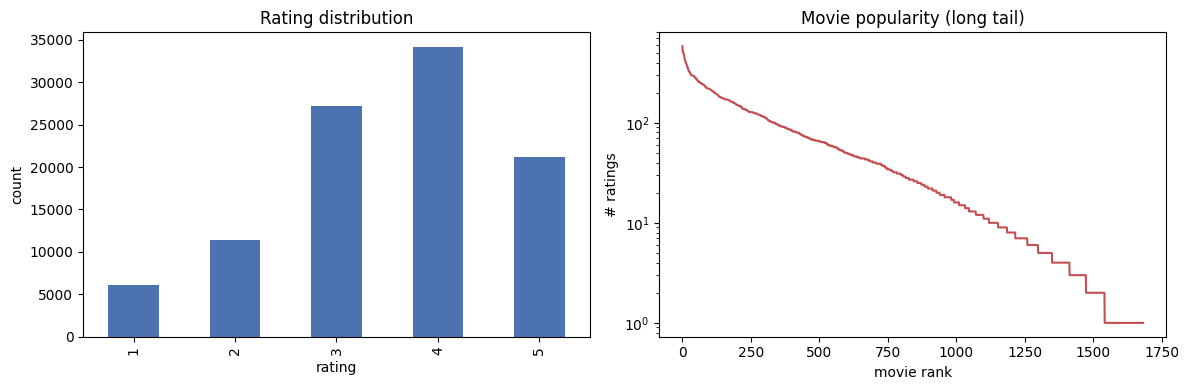

In [3]:
mu_all = ratings.rating.mean()
sparsity = len(ratings) / (n_users * n_items)
print(f"global mean rating: {mu_all:.3f}")
print(f"matrix sparsity:    {sparsity*100:.2f}% filled "
      f"({len(ratings):,} of {n_users*n_items:,} cells)")
print(f"ratings/user: median {int(ratings.groupby('user_id').size().median())}, "
      f"ratings/movie: median {int(ratings.groupby('item_id').size().median())}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ratings.rating.value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Rating distribution"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("count")

counts = ratings.groupby("item_id").size().sort_values(ascending=False).values
ax[1].plot(np.arange(1, len(counts)+1), counts, color="#C44E52")
ax[1].set_title("Movie popularity (long tail)")
ax[1].set_xlabel("movie rank"); ax[1].set_ylabel("# ratings"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()

## 3. Train / test split

We hold out **20%** of ratings as a test set (`random_state=42`, so the split is reproducible).
Every metric in this notebook is computed on the test set - ratings no model was trained on.

> **Note on leakage.** A random split over (user, item, rating) triples is the standard protocol for
> the *rating-prediction* (RMSE) task on MovieLens and is what published baselines use. It is not the
> same as a time-based split - if the goal were to forecast *future* behavior, we'd split by timestamp
> so the model can't peek at the future. We flag this explicitly because being deliberate about what the
> split does and doesn't simulate is the part that actually matters.

In [4]:
train, test = train_test_split(ratings, test_size=0.2, random_state=RNG)
mu = train.rating.mean()   # global mean, computed on TRAIN only
print(f"train: {len(train):,}   test: {len(test):,}   train global mean: {mu:.4f}")

def rmse(pred, truth):
    pred, truth = np.asarray(pred, float), np.asarray(truth, float)
    return float(np.sqrt(np.mean((pred - truth) ** 2)))

results = {}            # model name -> test RMSE
y_test = test.rating.values

train: 80,000   test: 20,000   train global mean: 3.5313


## 4. Rating-prediction baselines

The point of a baseline ladder is discipline: a fancy model is only worth its complexity if it beats
the dumbest thing that already works. Three rungs:

**4.1 Global mean** - predict the same number (the training average) for everyone. This is the floor.

**4.2 Bias model** - `prediction = mu + b_user + b_item`. It captures that some users rate generously and
some movies are simply better, with **no interaction** between user taste and movie. The biases are
*regularized* (shrunk toward zero for users/movies with few ratings) so a movie with 2 five-star ratings
doesn't look better than a classic with 400 ratings averaging 4.3.

**4.3 User-based collaborative filtering** - the port of the original Java approach, now turned into a
*predictor*. Cosine similarity between users on mean-centered ratings; predict from a user's `K` nearest
neighbors. This is the first model that uses *who is similar to whom*.

In [5]:
# ---- 4.1 Global mean ----
results["Global mean"] = rmse(np.full(len(test), mu), y_test)
print(f"Global mean RMSE: {results['Global mean']:.4f}")

Global mean RMSE: 1.1239


In [6]:
# ---- 4.2 Regularized bias model ----
LAM = 10.0  # regularization strength (shrinks biases for rarely-rated users/items)

ig = train.groupby("item_id").rating
b_i = (ig.sum() - mu * ig.count()) / (LAM + ig.count())          # item biases

tmp = train.assign(bi=train.item_id.map(b_i).fillna(0.0))
b_u = ((tmp.rating - mu - tmp.bi).groupby(tmp.user_id).sum()
       / (LAM + tmp.groupby("user_id").size()))                  # user biases

def bias_pred(df):
    return (mu + df.item_id.map(b_i).fillna(0.0)
              + df.user_id.map(b_u).fillna(0.0)).values

results["Bias model"] = rmse(bias_pred(test), y_test)
print(f"Bias model RMSE:  {results['Bias model']:.4f}")

Bias model RMSE:  0.9431


In [7]:
# ---- 4.3 User-based CF (cosine on mean-centered ratings, top-K neighbors) ----
# Build the train rating matrix (rows=users, cols=items); 0 = unobserved.
R = np.zeros((n_users + 1, n_items + 1), dtype=np.float32)
seen = np.zeros_like(R, dtype=bool)
for u, i, r in train[["user_id","item_id","rating"]].itertuples(index=False):
    R[u, i] = r; seen[u, i] = True

user_mean = np.array([R[u, seen[u]].mean() if seen[u].any() else 0.0
                      for u in range(n_users + 1)])

# Mean-center each user's ratings, then cosine similarity = normalized dot product.
Rc = np.zeros_like(R)
for u in range(1, n_users + 1):
    Rc[u, seen[u]] = R[u, seen[u]] - user_mean[u]
norms = np.linalg.norm(Rc, axis=1)
sim = Rc @ Rc.T
denom = np.outer(norms, norms); denom[denom == 0] = 1e-9
sim /= denom
np.fill_diagonal(sim, 0.0)

K = 40  # number of neighbours
def cf_predict(u, i):
    if not seen[:, i].any():                       # nobody rated this movie in train
        return user_mean[u] if user_mean[u] > 0 else mu
    raters = np.where(seen[:, i])[0]
    s = sim[u, raters]
    top = np.argsort(-s)[:K]
    raters, s = raters[top], s[top]
    keep = s > 0
    raters, s = raters[keep], s[keep]
    if len(s) == 0:
        return user_mean[u] if user_mean[u] > 0 else mu
    return user_mean[u] + np.sum(s * (R[raters, i] - user_mean[raters])) / np.sum(np.abs(s))

cf_preds = np.clip([cf_predict(u, i) for u, i
                    in test[["user_id","item_id"]].itertuples(index=False)], 1, 5)
results["User-based CF"] = rmse(cf_preds, y_test)
print(f"User-based CF RMSE: {results['User-based CF']:.4f}")

User-based CF RMSE: 0.9337


## 5. Content-based & hybrid (ported from the original Java)

These are the original prototype's approaches, reimplemented faithfully. They are **not** RMSE models -
they answer *"given this movie, what's similar"* and *"blend taste-similarity with content"*. They earn
their place for two jobs the rating models can't do:

- **Cold start:** a brand-new movie with zero ratings is invisible to CF and matrix factorization, but
  content-based can still place it by its genres.
- **Item-to-item / "more like this":** ranking neighbours of a movie the user just liked.

**Content-based** = one-hot genre vector per movie + cosine similarity (exactly the Java logic).
**Hybrid** = content-similarity scores + a bonus for items that user-based CF also surfaces (the Java
hybrid added a flat boost per collaborative hit; we keep that idea).

In [8]:
# Genre one-hot matrix (1682 x 19) -> cosine similarity between movies.
G = movies.set_index("item_id")[genre_cols].astype(float)
Gv = G.values
gnorm = np.linalg.norm(Gv, axis=1); gnorm[gnorm == 0] = 1e-9
Gn = Gv / gnorm[:, None]
item_ids = G.index.values
id_to_row = {i: r for r, i in enumerate(item_ids)}

def content_similar(item_id, topn=10):
    if item_id not in id_to_row:
        return []
    v = Gn[id_to_row[item_id]]
    scores = Gn @ v
    order = np.argsort(-scores)
    out = [(item_ids[r], scores[r]) for r in order if item_ids[r] != item_id]
    return out[:topn]

print("Content-based: movies most similar to 'Toy Story (1995)':")
for iid, sc in content_similar(1, 8):
    print(f"  {sc:.2f}  {title_of[iid]}")

Content-based: movies most similar to 'Toy Story (1995)':
  1.00  Aladdin and the King of Thieves (1996)
  0.87  Goofy Movie, A (1995)
  0.87  Aladdin (1992)
  0.82  Oliver & Company (1988)
  0.82  Gumby: The Movie (1995)
  0.82  Beavis and Butt-head Do America (1996)
  0.82  Winnie the Pooh and the Blustery Day (1968)
  0.82  Heavyweights (1994)


In [9]:
def hybrid_recommend(user_id, liked_item, topn=10, cf_boost=0.5):
    # content scores for all movies vs the liked movie
    v = Gn[id_to_row[liked_item]]
    score = {iid: float(Gn[id_to_row[iid]] @ v) for iid in item_ids if iid != liked_item}
    # collaborative boost: items this user's neighbours rate highly
    if seen[user_id].any():
        nbrs = np.argsort(-sim[user_id])[:K]
        for i in np.where(seen[nbrs].any(axis=0))[0]:
            if i >= 1 and not seen[user_id, i] and i in score:
                score[i] += cf_boost
    ranked = sorted(score, key=score.get, reverse=True)[:topn]
    return [(i, score[i]) for i in ranked]

print("Hybrid recs for user 1 who liked 'Toy Story (1995)':")
for iid, sc in hybrid_recommend(1, 1, 8):
    print(f"  {sc:.2f}  {title_of[iid]}")

Hybrid recs for user 1 who liked 'Toy Story (1995)':
  1.50  Aladdin and the King of Thieves (1996)
  1.37  Aladdin (1992)
  1.37  Goofy Movie, A (1995)
  1.32  Santa Clause, The (1994)
  1.32  Home Alone (1990)
  1.32  George of the Jungle (1997)
  1.32  Heavyweights (1994)
  1.32  Flintstones, The (1994)


## 6. Matrix factorization (Funk SVD)

The headline model. Instead of comparing whole users (CF), we learn a short **latent vector** for every
user and every movie, so that `rating ~= mu + b_u + b_i + (user_vector | movie_vector)`. The dot product
captures *interaction* - e.g. "this user likes gritty crime dramas" lines up with "this movie is a gritty
crime drama" - which the bias model structurally cannot.

We train by **stochastic gradient descent**, one rating at a time, minimizing squared error with L2
regularization on every parameter. Configuration (fixed in advance, not tuned on the test set):

`K=40 factors | lr0=0.01 with 0.95/epoch decay | reg=0.05 | 25 epochs | global mean + user/item biases`.

In [10]:
K_MF, lr0, reg, EPOCHS, decay = 40, 0.01, 0.05, 25, 0.95
rng = np.random.default_rng(RNG)
P  = rng.normal(0, 0.1, (n_users + 1, K_MF))   # user factors
Q  = rng.normal(0, 0.1, (n_items + 1, K_MF))   # item factors
bu = np.zeros(n_users + 1); bi = np.zeros(n_items + 1)

tr_arr = train[["user_id","item_id","rating"]].values.astype(np.int64)
lr = lr0
for ep in range(EPOCHS):
    rng.shuffle(tr_arr)
    sse = 0.0
    for u, i, r in tr_arr:
        pred = mu + bu[u] + bi[i] + P[u] @ Q[i]
        e = r - pred; sse += e * e
        bu[u] += lr * (e - reg * bu[u])
        bi[i] += lr * (e - reg * bi[i])
        Pu = P[u].copy()
        P[u] += lr * (e * Q[i] - reg * P[u])
        Q[i] += lr * (e * Pu   - reg * Q[i])
    lr *= decay
    if ep == 0 or (ep + 1) % 5 == 0:
        print(f"epoch {ep+1:2d}/{EPOCHS}  train RMSE {np.sqrt(sse/len(tr_arr)):.4f}  lr {lr:.4f}")

def mf_predict(df):
    out = [mu + bu[u] + bi[i] + P[u] @ Q[i]
           for u, i in df[["user_id","item_id"]].itertuples(index=False)]
    return np.clip(out, 1, 5)

results["Matrix Factorization"] = rmse(mf_predict(test), y_test)
print(f"\nMatrix Factorization test RMSE: {results['Matrix Factorization']:.4f}")

epoch  1/25  train RMSE 1.0223  lr 0.0095
epoch  5/25  train RMSE 0.9153  lr 0.0077
epoch 10/25  train RMSE 0.8817  lr 0.0060
epoch 15/25  train RMSE 0.8473  lr 0.0046
epoch 20/25  train RMSE 0.8159  lr 0.0036
epoch 25/25  train RMSE 0.7902  lr 0.0028

Matrix Factorization test RMSE: 0.9222


## 7. RMSE comparison

Every model beats the one below it, and each step is a real reduction in error - which is exactly what
justifies the added complexity. Matrix factorization wins on RMSE, the metric it was built to optimize.

,model,test_RMSE,% better than global mean
0,Global mean,1.123860,0.0
1,Bias model,0.943150,16.1
2,User-based CF,0.933676,16.9
3,Matrix Factorization,0.922200,17.9


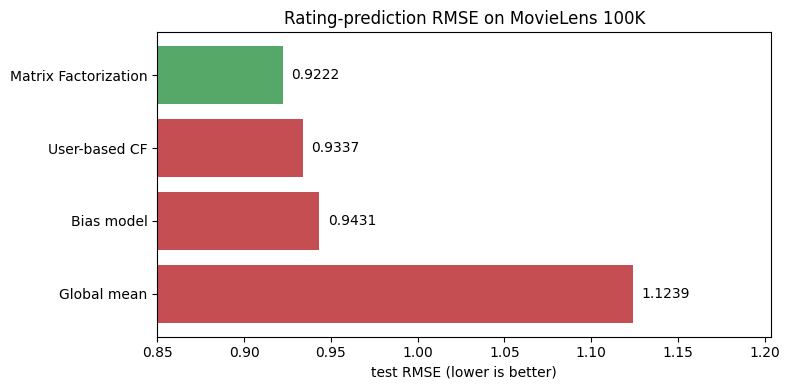

In [11]:
res = (pd.DataFrame({"model": list(results), "test_RMSE": list(results.values())})
       .sort_values("test_RMSE", ascending=False).reset_index(drop=True))
base = results["Global mean"]
res["% better than global mean"] = (100 * (base - res.test_RMSE) / base).round(1)
display(res)

plt.figure(figsize=(8, 4))
order = res.sort_values("test_RMSE")
colors = ["#C44E52" if m != "Matrix Factorization" else "#55A868" for m in order.model]
plt.barh(order.model, order.test_RMSE, color=colors)
for y, v in zip(range(len(order)), order.test_RMSE):
    plt.text(v + 0.005, y, f"{v:.4f}", va="center")
plt.xlabel("test RMSE (lower is better)"); plt.title("Rating-prediction RMSE on MovieLens 100K")
plt.xlim(0.85, max(res.test_RMSE) + 0.08); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 8. Top-N ranking - and an honest finding

RMSE measures how well we predict a *known* rating. But a real recommender shows a user a *ranked list*
of things they haven't seen. So we also measure **precision@10** and **recall@10**: of the 10 movies we
put in front of a user, how many are ones they actually rated >= 4 in the held-out test set.

We compare matrix factorization against a **popularity** baseline (recommend the most-rated movies to
everyone). The result is the kind of thing that's easy to hide and important to report:

In [12]:
def topn_eval(score_fn, N=10, thresh=4):
    relevant = test[test.rating >= thresh].groupby("user_id").item_id.apply(set).to_dict()
    train_seen = train.groupby("user_id").item_id.apply(set).to_dict()
    all_items = np.arange(1, n_items + 1)
    precs, recs = [], []
    for u, rel in relevant.items():
        cand = all_items[~np.isin(all_items, list(train_seen.get(u, set())))]
        top = cand[np.argsort(-score_fn(u, cand))[:N]]
        hits = len(set(top.tolist()) & rel)
        precs.append(hits / N); recs.append(hits / len(rel))
    return float(np.mean(precs)), float(np.mean(recs))

pop_arr = np.zeros(n_items + 1)
for i, c in train.groupby("item_id").size().items():
    pop_arr[i] = c

mf_score  = lambda u, cand: mu + bu[u] + bi[cand] + Q[cand] @ P[u]
pop_score = lambda u, cand: pop_arr[cand]

p_mf,  r_mf  = topn_eval(mf_score)
p_pop, r_pop = topn_eval(pop_score)
print(f"Matrix Factorization   precision@10 = {p_mf:.3f}   recall@10 = {r_mf:.3f}")
print(f"Popularity baseline    precision@10 = {p_pop:.3f}   recall@10 = {r_pop:.3f}")

Matrix Factorization   precision@10 = 0.070   recall@10 = 0.048
Popularity baseline    precision@10 = 0.136   recall@10 = 0.137


**The honest finding:** the rating-optimized MF model *loses to popularity* on top-N ranking. This is
a well-documented effect on MovieLens, and it's worth understanding rather than hiding:

- **Why it happens.** MF is trained to minimize squared error on *observed* ratings. Observed ratings are
  themselves popularity-biased (people mostly rate films they sought out), and most held-out "relevant"
  items are popular films almost everyone likes. A model that just ranks by popularity scores those easy
  hits directly; an RMSE-optimized model spends its capacity getting the *magnitude* of niche ratings right.
- **Why popularity is not actually the answer.** It recommends the **same list to everyone** - zero
  personalization. It can't help a user discover anything off the beaten path, and it has nothing to say
  about a new or niche item. Its "win" is a measurement artifact of this metric + dataset, not a better
  product.
- **The principled fix.** If top-N ranking is the goal, optimize for *ranking*, not rating: methods like
  **BPR** (Bayesian Personalized Ranking) or **implicit-feedback ALS** train on the order of items rather
  than the rating value, and close most of this gap while staying personalized.

MF still produces genuinely personalized lists - here are its top picks for one user, none of which are
just "the most popular movies":

In [13]:
u = 1
train_seen_u = set(train[train.user_id == u].item_id)
cand = np.array([i for i in range(1, n_items + 1) if i not in train_seen_u])
top = cand[np.argsort(-mf_score(u, cand))[:10]]
print(f"Matrix-factorization top-10 personalized picks for user {u}:")
for rank, iid in enumerate(top, 1):
    print(f"  {rank:2d}. {title_of[iid]}")

Matrix-factorization top-10 personalized picks for user 1:
   1. Close Shave, A (1995)
   2. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
   3. Lawrence of Arabia (1962)
   4. Paradise Lost: The Child Murders at Robin Hood Hills (1996)
   5. L.A. Confidential (1997)
   6. Chinatown (1974)
   7. Manchurian Candidate, The (1962)
   8. Fargo (1996)
   9. Secrets & Lies (1996)
  10. Rear Window (1954)


## 9. Takeaways & next steps

**What this notebook establishes:**
- A clean, reproducible pipeline on **real MovieLens 100K** with a **held-out test set** - every number
  is measured, never assumed.
- A **baseline ladder** (global mean -> bias -> CF -> MF) where each model beats the previous one, so the
  complexity of matrix factorization is *justified*, not assumed.
- **Matrix factorization wins on RMSE** (~0.92), a clear improvement over the bias model and CF.
- An **honest ranking evaluation**: on top-N, a popularity baseline beats rating-optimized MF - a known
  effect that points to the right next model rather than something to sweep under the rug.

**Principled next steps:**
1. **Ranking-aware training** - BPR or implicit ALS to optimize the metric users actually experience.
2. **Hyperparameter search with a validation fold** - tune `K`, `reg`, `lr` without ever touching the test set.
3. **Hybrid cold-start** - fall back to the content-based model for new movies/users MF can't place.
4. **Richer signal** - timestamps (recency), genres as side-features in a factorization-machine setup.

**Method principles followed throughout:** real data; leakage-free, reproducible split; always compare
against a baseline; report concrete metrics; and be candid about each model's failure modes.